C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\874032370.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


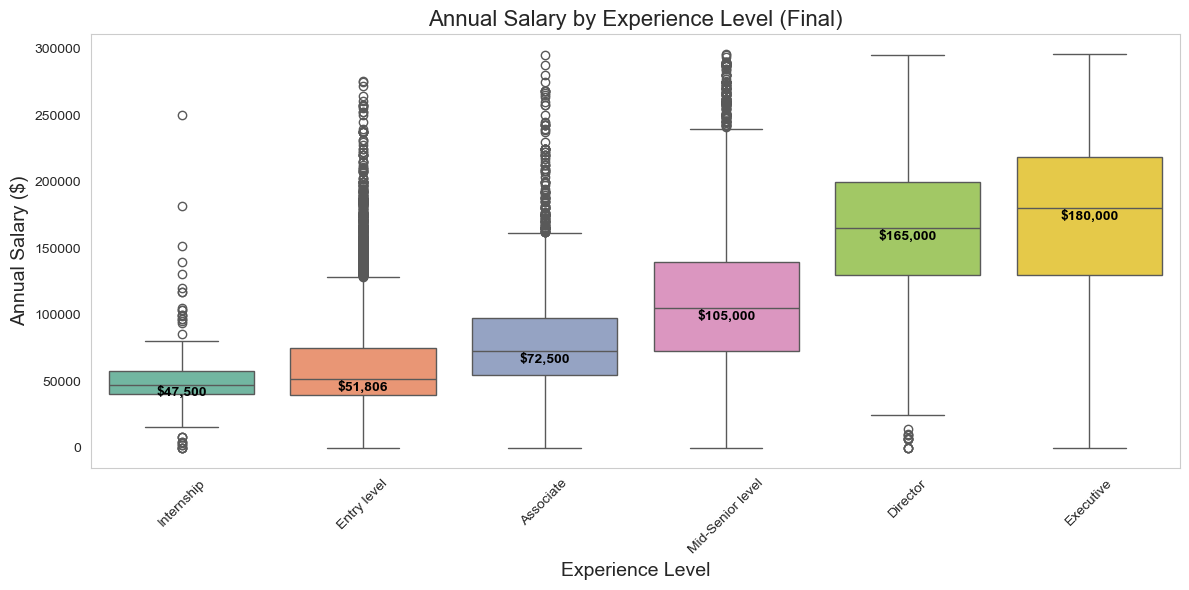

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("job_postings_cleaned.csv")

# Clean data
df = df[
    (df['annual_salary'].notna()) &
    (df['annual_salary'] > 0) &
    (df['annual_salary'] < 300000) &
    (df['formatted_experience_level'] != 'UNKNOWN')
]

# Calculate medians for ordering and labels
medians = df.groupby('formatted_experience_level')['annual_salary'].median().sort_values()

# Set up the style
sns.set_style("whitegrid")

# Set up the plot
plt.figure(figsize=(12,6))
palette = sns.color_palette("Set2", n_colors=len(medians))  # Different pastel colors

# Create the boxplot with custom palette
ax = sns.boxplot(
    data=df,
    x='formatted_experience_level',
    y='annual_salary',
    order=medians.index,
    palette=palette
)

# Titles and labels
plt.title('Annual Salary by Experience Level (Final)', fontsize=16)
plt.xlabel('Experience Level', fontsize=14)
plt.ylabel('Annual Salary ($)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')

# Add median salary labels
for i, median in enumerate(medians):
    ax.text(i, median - 1000, f'${median:,.0f}', 
            ha='center', va='top', fontweight='bold', fontsize=10, color='black')

# Tight layout for better spacing
plt.tight_layout()
plt.show()


In [26]:
import os, sys
sys.path.append('.')   
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from clean import clean_df
from data import load_data

RAW_CSV   = 'postings.csv'
CLEAN_CSV = 'job_postings_cleaned.csv'
CFG_PATH  = os.path.join('..', 'config', 'config.yaml')

print("RAW_CSV   →", RAW_CSV)
print("CLEAN_CSV →", CLEAN_CSV)
print("CFG_PATH  →", CFG_PATH)
print("Notebook cwd:", os.getcwd())

RAW_CSV   → postings.csv
CLEAN_CSV → job_postings_cleaned.csv
CFG_PATH  → ..\config\config.yaml
Notebook cwd: c:\GaTech\Spring Semester 2025\Deep Learning - CS 7643\Final Project\DL_Final_Project\LinkedInJobPostings_Code\data


In [27]:
with open(CFG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

df_clean = clean_df(RAW_CSV, output_path=CLEAN_CSV, max_length=200)
print(f">>> Cleaned data: {df_clean.shape[0]} rows × {df_clean.shape[1]} cols")
df_clean.head()

>>> Cleaned data: 36061 rows × 17 cols


,company_name,title,description,pay_period,location,views,formatted_work_type,remote_allowed,application_type,formatted_experience_level,sponsored,work_type,normalized_salary,zip_code,fips,annual_salary,state
0,Corcoran Sawyer Smith,Marketing Coordinator,job descriptiona leading real estate firm in n...,HOURLY,"Princeton, NJ",20.0,Full-time,0.0,ComplexOnsiteApply,UNKNOWN,0,FULL_TIME,38480.0,8540.0,34021.0,38480.0,NJ
1,UNKNOWN,Mental Health Therapist/Counselor,at aspen therapy and wellness we are committed...,HOURLY,"Fort Collins, CO",1.0,Full-time,0.0,ComplexOnsiteApply,UNKNOWN,0,FULL_TIME,83200.0,80521.0,8069.0,83200.0,CO
2,The National Exemplar,Assitant Restaurant Manager,the national exemplar is accepting application...,YEARLY,"Cincinnati, OH",8.0,Full-time,0.0,ComplexOnsiteApply,UNKNOWN,0,FULL_TIME,55000.0,45202.0,39061.0,55000.0,OH
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,senior associate attorney elder law trusts and...,YEARLY,"New Hyde Park, NY",16.0,Full-time,0.0,ComplexOnsiteApply,UNKNOWN,0,FULL_TIME,157500.0,11040.0,36059.0,157500.0,NY
4,UNKNOWN,Service Technician,looking for hvac service tech with experience ...,YEARLY,"Burlington, IA",3.0,Full-time,0.0,ComplexOnsiteApply,UNKNOWN,0,FULL_TIME,70000.0,52601.0,19057.0,70000.0,IA


In [28]:
# Build train/val/test splits
with open(CFG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

train_df, val_df, test_df = load_data(CLEAN_CSV, cfg)
print(f"Train: {len(train_df)} rows")
print(f"Valid: {len(val_df)} rows")
print(f" Test: {len(test_df)} rows")

Train: 26053 rows
Valid: 4598 rows
 Test: 5410 rows


In [29]:
# High-level overview of the cleaned data
df_clean.info()
df_clean.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36061 entries, 0 to 36060
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   company_name                36061 non-null  object 
 1   title                       36061 non-null  object 
 2   description                 36061 non-null  object 
 3   pay_period                  36061 non-null  object 
 4   location                    36061 non-null  object 
 5   views                       36061 non-null  float64
 6   formatted_work_type         36061 non-null  object 
 7   remote_allowed              36061 non-null  float64
 8   application_type            36061 non-null  object 
 9   formatted_experience_level  36061 non-null  object 
 10  sponsored                   36061 non-null  int64  
 11  work_type                   36061 non-null  object 
 12  normalized_salary           36061 non-null  float64
 13  zip_code                    360

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_name,36061,10339,UNKNOWN,509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,36061,24350,Senior Accountant,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,36061,32495,overview today sca health has grown to 11 000 ...,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pay_period,36061,5,YEARLY,20623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,36061,4520,United States,2605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,36061.0,NaN,NaN,NaN,19.390644,122.751731,0.0,3.0,5.0,10.0,9975.0
formatted_work_type,36061,7,Full-time,29126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_allowed,36061.0,NaN,NaN,NaN,0.134799,0.341514,0.0,0.0,0.0,0.0,1.0
application_type,36061,4,OffsiteApply,21703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
formatted_experience_level,36061,7,Mid-Senior level,12904,NaN,NaN,NaN,NaN,NaN,NaN,NaN


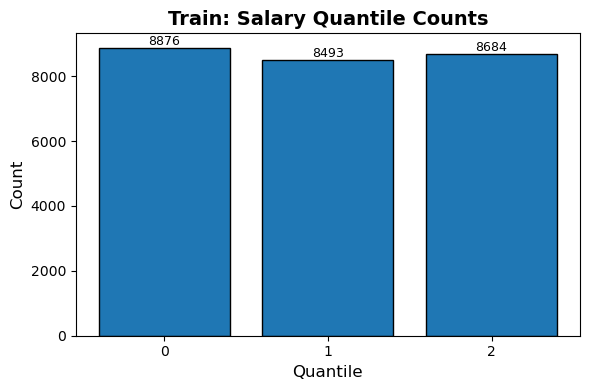

In [30]:
import matplotlib.pyplot as plt

# Compute counts
counts = train_df['salary_quantile'].value_counts().sort_index()

# Plot and capture the Axes
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
bars = ax.bar(counts.index.astype(str), counts.values, edgecolor='black')

# Annotate each bar with its count
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,  # x-position: center of bar
        yval,                             # y-position: top of bar
        f"{int(yval)}",                   # text
        ha='center',                      # horizontal alignment
        va='bottom',                      # vertical alignment
        fontsize=9
    )

# Labels and title
ax.set_title('Train: Salary Quantile Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantile', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

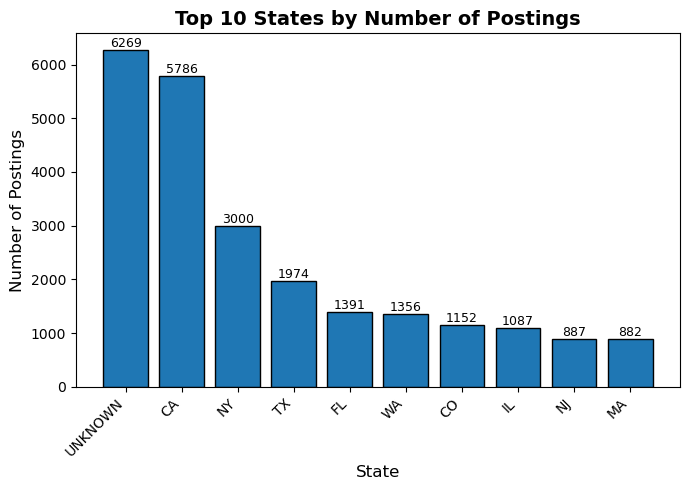

In [31]:
# Compute top 10 states
top_states = df_clean['state'].value_counts().head(10)

# Create vertical bar plot
fig, ax = plt.subplots(figsize=(7,5), dpi=100)
bars = ax.bar(top_states.index, top_states.values, edgecolor='black')

# Annotate each bar with its count
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Labels and title
ax.set_title('Top 10 States by Number of Postings', fontsize=14, fontweight='bold')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Number of Postings', fontsize=12)

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\2372116989.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))


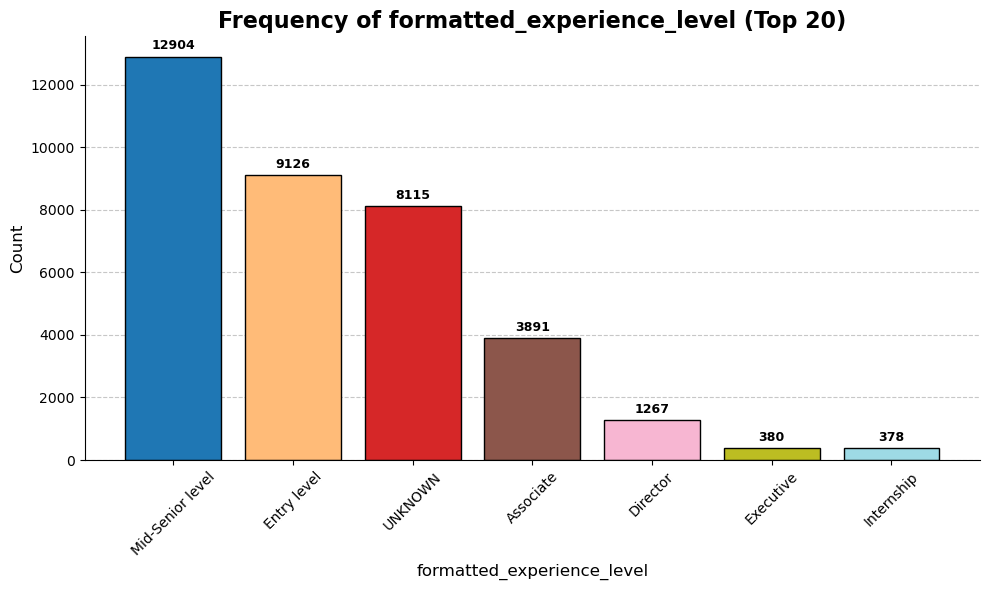

C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\2372116989.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))


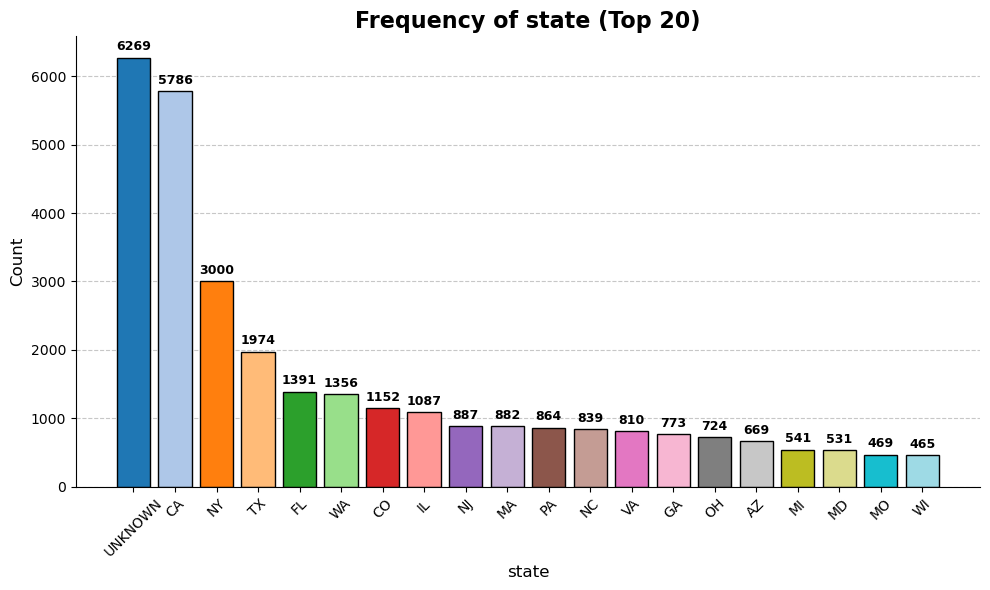

C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\2372116989.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))


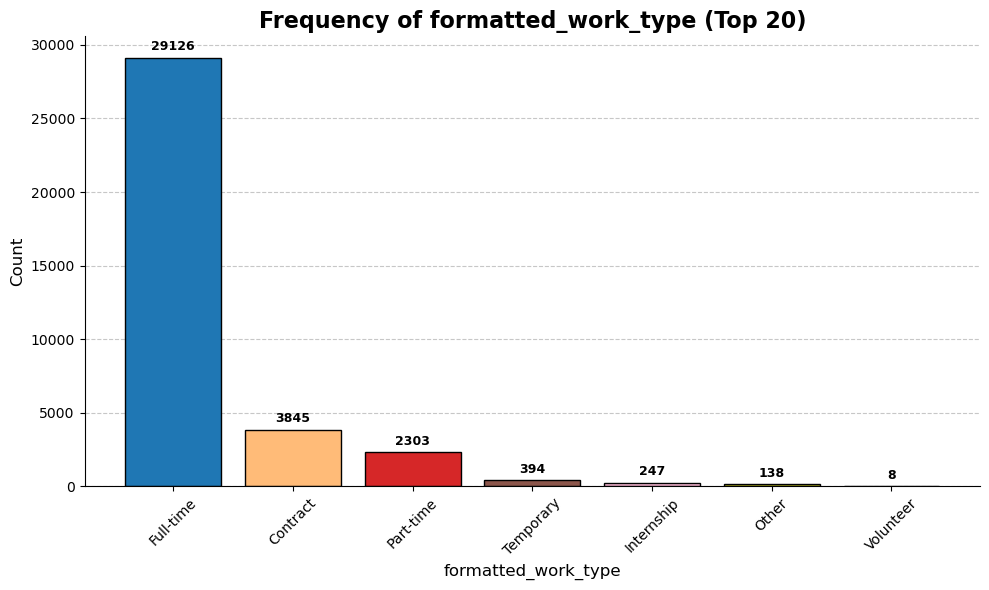

C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\2372116989.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))


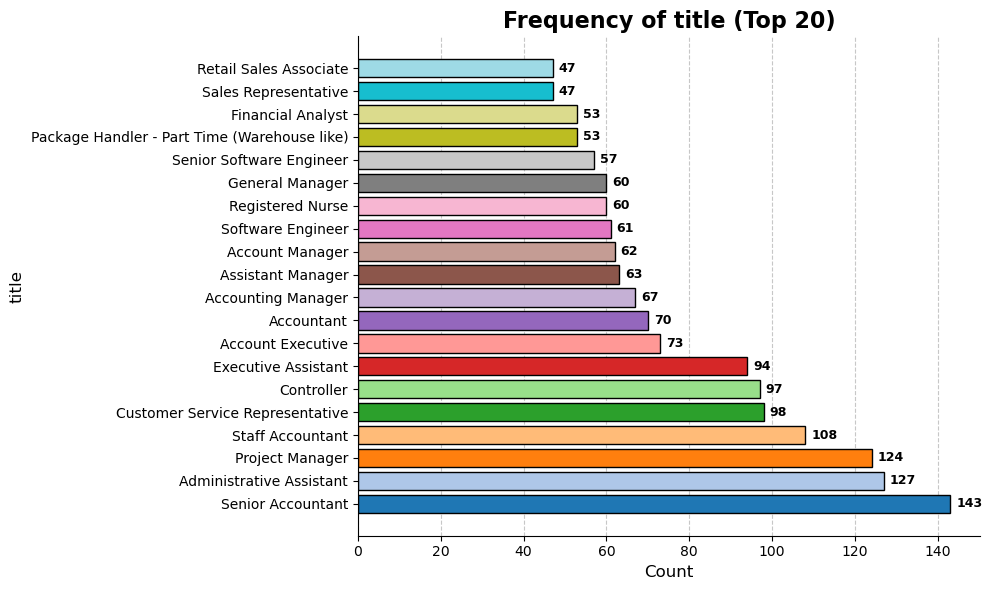

C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\2372116989.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(counts))


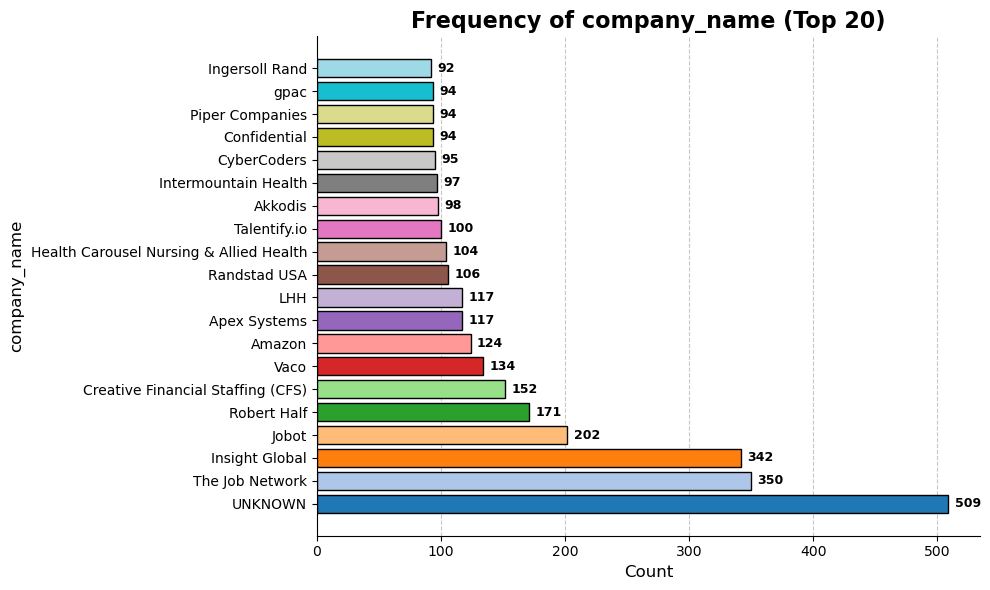

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

# (1) which cols go vertical vs horizontal
vertical_cols   = ['formatted_experience_level', 'state', 'formatted_work_type']
horizontal_cols = ['title', 'company_name']

# (2) plotting helpers (unchanged)
def plot_enhanced_bar(counts, title, xlabel):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    cmap = plt.cm.get_cmap('tab20', len(counts))
    bars = ax.bar(counts.index, counts.values,
                  color=cmap(range(len(counts))),
                  edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + max(counts.values)*0.01,
                f'{int(h)}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

def plot_enhanced_barh(counts, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    cmap = plt.cm.get_cmap('tab20', len(counts))
    bars = ax.barh(counts.index, counts.values,
                   color=cmap(range(len(counts))),
                   edgecolor='black')

    # flip so the largest is on top
    ax.invert_yaxis()

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(counts.values)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{int(w)}',
                va='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Count', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()

# (3) Plot them
for col in vertical_cols:
    counts = df_clean[col].value_counts().nlargest(top_n)
    plot_enhanced_bar(
        counts,
        f'Frequency of {col} (Top {top_n})',
        col
    )

for col in horizontal_cols:
    counts = df_clean[col].value_counts().nlargest(top_n)
    plot_enhanced_barh(
        counts,
        f'Frequency of {col} (Top {top_n})',
        col
    )


=== Overall Salary Summary ===
               min          max           mean   median           std
annual_salary  0.0  535600000.0  203676.486339  80000.0  5.098466e+06

=== Salary Summary by Tercile ===
                     min          max           mean    median           std
salary_tercile                                                              
Low                  0.0      60000.0   40763.385101   43066.4  1.467321e+04
Mid              60008.0     107506.5   82112.834544   80080.0  1.358189e+04
High            107515.2  535600000.0  489112.267378  145000.0  8.824544e+06

=== Salary Summary by Experience Level ===
                                min          max           mean    median  \
formatted_experience_level                                                  
Associate                     1.500     435000.0   80895.826605   72800.0   
Director                      1.000     750000.0  171565.862944  166650.0   
Entry level                  15.895  535600000.0  244625.

C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\286624216.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_tercile = df_salary.groupby('salary_tercile')['annual_salary'] \


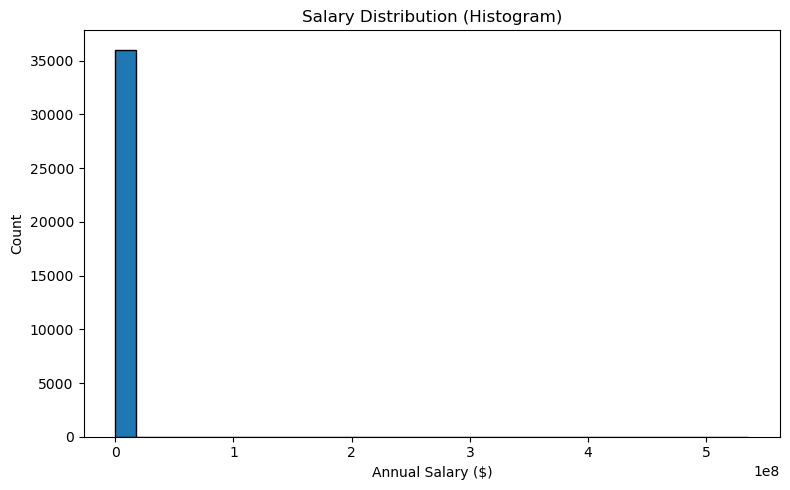

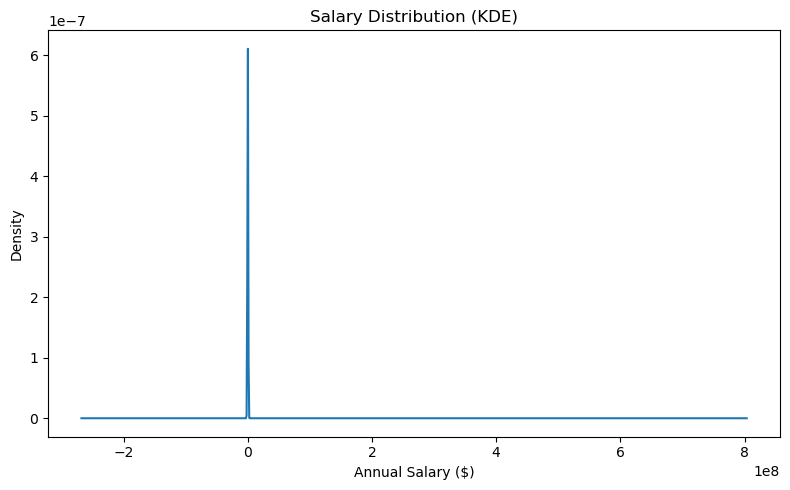

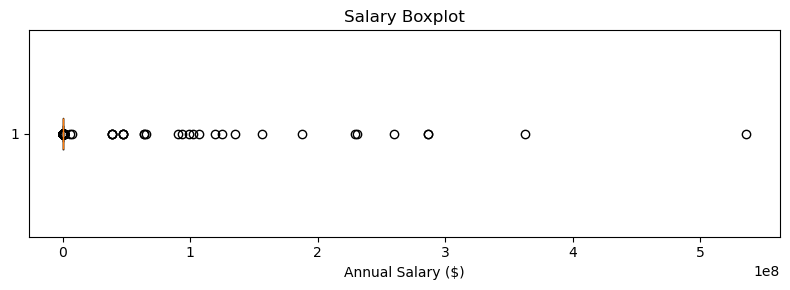

In [33]:
# Summary Statistics and Distribution Plots 

# Copy cleaned data
df_salary = df_clean.copy()

# Salary terciles (Low / Mid / High)
df_salary['salary_tercile'] = pd.qcut(
    df_salary['annual_salary'], 
    q=3,
    labels=['Low','Mid','High']
)

# Compute summary tables
summary_overall = df_salary['annual_salary'].agg(['min','max','mean','median','std'])
summary_tercile = df_salary.groupby('salary_tercile')['annual_salary'] \
                           .agg(['min','max','mean','median','std'])
summary_experience = df_salary.groupby('formatted_experience_level')['annual_salary'] \
                             .agg(['min','max','mean','median','std'])

# Print them
print("=== Overall Salary Summary ===")
print(summary_overall.to_frame().T)
print("\n=== Salary Summary by Tercile ===")
print(summary_tercile)
print("\n=== Salary Summary by Experience Level ===")
print(summary_experience)

# Histogram of annual_salary
plt.figure(figsize=(8,5), dpi=100)
df_salary['annual_salary'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Salary Distribution (Histogram)')
plt.xlabel('Annual Salary ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# KDE of annual_salary
plt.figure(figsize=(8,5), dpi=100)
df_salary['annual_salary'].plot(kind='kde')
plt.title('Salary Distribution (KDE)')
plt.xlabel('Annual Salary ($)')
plt.tight_layout()
plt.show()

# Boxplot of annual_salary
plt.figure(figsize=(8,3), dpi=100)
plt.boxplot(df_salary['annual_salary'], vert=False)
plt.title('Salary Boxplot')
plt.xlabel('Annual Salary ($)')
plt.tight_layout()
plt.show()


C:\Users\eddie\AppData\Local\Temp\ipykernel_15392\3480874205.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(salary_by_level, labels=levels, patch_artist=True)


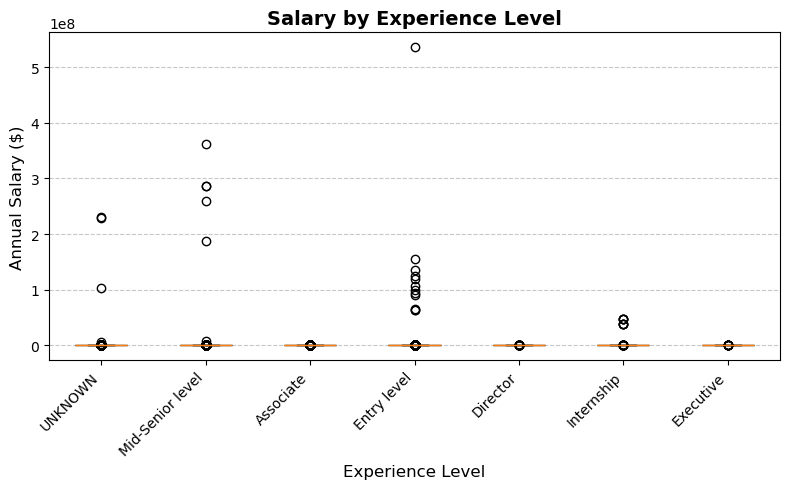

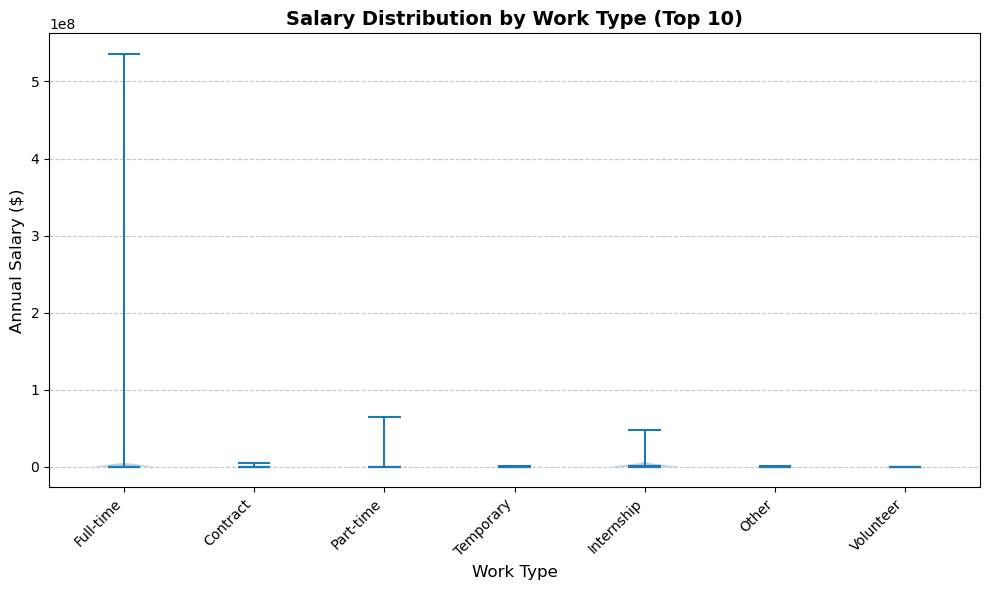

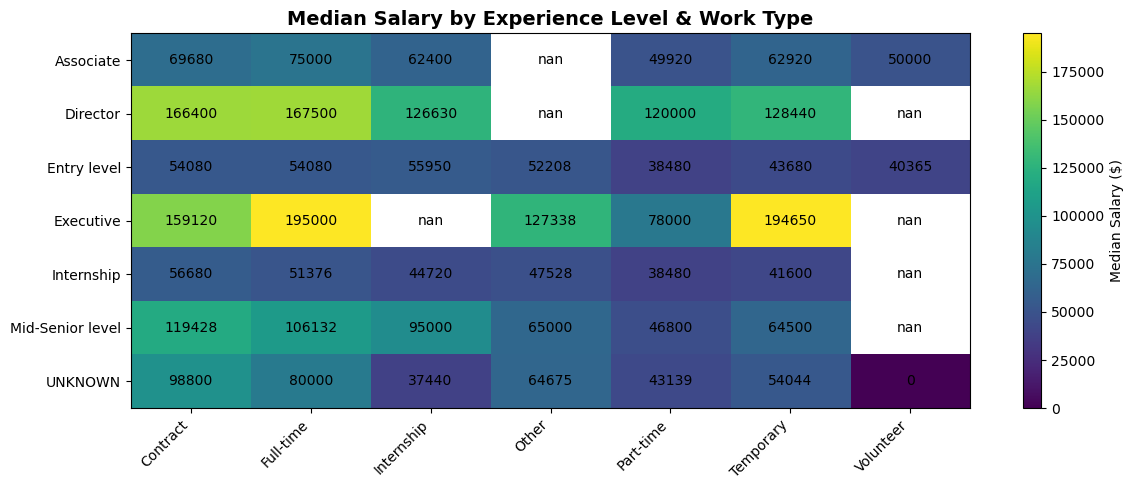

In [34]:
# Salary vs. Category 

import numpy as np
import matplotlib.pyplot as plt

# (1) Boxplot: annual_salary by experience level
levels = df_clean['formatted_experience_level'].unique()
salary_by_level = [
    df_clean.loc[df_clean['formatted_experience_level'] == lvl, 'annual_salary']
    for lvl in levels
]

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
ax.boxplot(salary_by_level, labels=levels, patch_artist=True)
ax.set_title('Salary by Experience Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Experience Level', fontsize=12)
ax.set_ylabel('Annual Salary ($)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# (2) Violin plot: distribution by work type (top 10)
top_types = df_clean['formatted_work_type'].value_counts().nlargest(10).index
data_types = [
    df_clean.loc[df_clean['formatted_work_type'] == wt, 'annual_salary']
    for wt in top_types
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
parts = ax.violinplot(data_types, showmeans=True, showmedians=True)
ax.set_title('Salary Distribution by Work Type (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Work Type', fontsize=12)
ax.set_ylabel('Annual Salary ($)', fontsize=12)
ax.set_xticks(np.arange(1, len(top_types) + 1))
ax.set_xticklabels(top_types, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# (3) Heatmap: median salary by experience level & work type
subset = df_clean[df_clean['formatted_work_type'].isin(top_types)]
pivot = subset.pivot_table(
    index='formatted_experience_level',
    columns='formatted_work_type',
    values='annual_salary',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(12, 5), dpi=100)
im = ax.imshow(pivot, aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# overlay median values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        ax.text(
            j, i, f"{val:.0f}",
            ha='center', va='center',
            color='white' if val < pivot.values.max()/2 else 'black'
        )

cbar = fig.colorbar(im, ax=ax, orientation='vertical', label='Median Salary ($)')
ax.set_title('Median Salary by Experience Level & Work Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

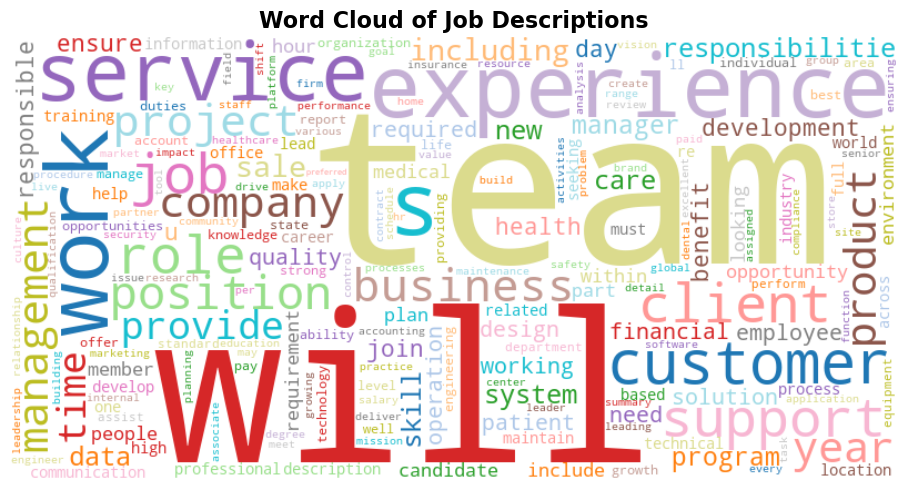

Top 20 Words in Descriptions:


,Word,Count
0,and,392259
1,the,207463
2,to,200923
3,of,149523
4,a,135439
5,in,115384
6,for,93102
7,with,89005
8,our,63908
9,is,62316


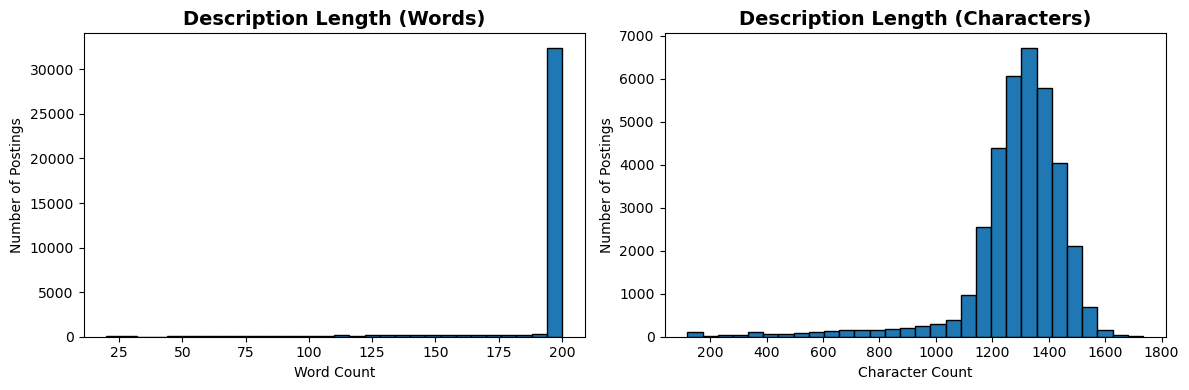

In [35]:
# Textual Quick-Wins on Job Descriptions 

import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import pandas as pd

# Build a single text blob from all cleaned descriptions
text = ' '.join(df_clean['description'].tolist())

# Word-cloud of description text
wc = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='tab20',
    collocations=False
).generate(text)

plt.figure(figsize=(10, 5), dpi=100)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Descriptions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 20 most common words
words = text.split()
top_n = 20
freq = Counter(words)
common = freq.most_common(top_n)
df_common = pd.DataFrame(common, columns=['Word','Count'])
print(f"Top {top_n} Words in Descriptions:")
display(df_common)

df_clean['desc_len_words'] = df_clean['description'].str.split().map(len)
df_clean['desc_len_chars'] = df_clean['description'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)

# words
axes[0].hist(df_clean['desc_len_words'], bins=30, edgecolor='black')
axes[0].set_title('Description Length (Words)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Postings')

# characters
axes[1].hist(df_clean['desc_len_chars'], bins=30, edgecolor='black')
axes[1].set_title('Description Length (Characters)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Number of Postings')

plt.tight_layout()
plt.show()
